# 02 — Train Emulators (Multi-z): GSMF, HMF, fGas, Pk-ratio

Multi-snapshot emulators with redshift interpolation support.
All models saved to `../models/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import os

from cosmo_hydro_emu.pca import *
from cosmo_hydro_emu.viz import *
from cosmo_hydro_emu.load_hacc import *
from cosmo_hydro_emu.emu import *
from cosmo_hydro_emu.gp import *
from cosmo_hydro_emu.snapshot_utils import SNAPSHOT_IDS, get_snapshot_redshifts

## Configuration

In [2]:
DirIn = '../data/400MPC_RUNS_5SG_2COSMO_PARAM/HAvoCC/'
DirIn_pk = '../data/scidac-olcf-pk_3/'

start_sim_idx = 1
num_sims = 39
# Training-time PCA budget. Inference auto-syncs basis size from the saved
# pickle (via load_model_autosync), so this value is not constrained by the
# Inference YAML's exp_variance — pick whatever gives the best emulator.
exp_variance = 0.999

z_initial = 200

seed_mass_scale = 1e6
vkin_scale = 1e4
eps_scale = 1e1

do_train = True

## Load parameters

In [3]:
fileIn = '../data/FinalDesign.txt'
params_all = np.loadtxt(fileIn, delimiter=",", skiprows=1)
# Design CSV row K corresponds to RUN_K (both 0-indexed); row 0 = RUN000.
# When loaders use start_sim_idx=1, num_sims=39 they read RUN001..RUN039, so
# the matching slice is rows [1:40] = [start_sim_idx : start_sim_idx + num_sims].
params32 = params_all[start_sim_idx : start_sim_idx + num_sims]

params32[:, 2] = params32[:, 2] / seed_mass_scale
params32[:, 3] = params32[:, 3] / vkin_scale
params32[:, 4] = params32[:, 4] / eps_scale

print('params32 shape:', params32.shape)

params32 shape: (39, 7)


## Train/test split

In [4]:
test_sim_indices = [3, 11, 19, 27, 35]
train_sim_indices = [i for i in range(num_sims) if i not in test_sim_indices]

params_train = params32[train_sim_indices]
params_test = params32[test_sim_indices]

print(f'Train: {len(train_sim_indices)} sims, Test: {len(test_sim_indices)} sims')

Train: 34 sims, Test: 5 sims


## Snapshot setup

In [5]:
z_all, a_all = get_snapshot_redshifts(SNAPSHOT_IDS, z_initial=z_initial)

print(f'{len(SNAPSHOT_IDS)} snapshots, z range: [{z_all.min():.3f}, {z_all.max():.3f}]')
print()
for i, (sid, z, a) in enumerate(zip(SNAPSHOT_IDS, z_all, a_all)):
    print(f'  [{i:2d}] snap {sid:3d}  z = {z:.4f}  a = {a:.4f}')

11 snapshots, z range: [0.000, 2.004]

  [ 0] snap 205  z = 2.0036  a = 0.3329
  [ 1] snap 224  z = 1.7534  a = 0.3632
  [ 2] snap 247  z = 1.5012  a = 0.3998
  [ 3] snap 275  z = 1.2503  a = 0.4444
  [ 4] snap 310  z = 0.9996  a = 0.5001
  [ 5] snap 355  z = 0.7490  a = 0.5717
  [ 6] snap 415  z = 0.4987  a = 0.6673
  [ 7] snap 479  z = 0.3001  a = 0.7692
  [ 8] snap 498  z = 0.2509  a = 0.7994
  [ 9] snap 567  z = 0.0998  a = 0.9093
  [10] snap 624  z = 0.0000  a = 1.0000


## GSMF — Galaxy Stellar Mass Function (11 snapshots)

In [6]:
# Load multi-snapshot GSMF data
stellar_mass, gsmf_arr = read_gsmf_all_snaps(DirIn, num_sims, SNAPSHOT_IDS, start_sim_idx=start_sim_idx)
print('stellar_mass shape:', stellar_mass.shape)
print('gsmf_arr shape:', gsmf_arr.shape)

# Mass cut
mlim1, mlim2 = mass_conds('GSMF')
mass_cond = np.where((stellar_mass > mlim1) & (stellar_mass < mlim2))[0]

# NaN interpolation per snapshot
for s in range(gsmf_arr.shape[1]):
    gsmf_arr[:, s, :] = fill_nan_with_interpolation(gsmf_arr[:, s, :], 'linear')

gsmf_y_vals = 10**gsmf_arr[:, :, mass_cond]  # shape (39, 11, n_bins)
gsmf_y_ind = stellar_mass[mass_cond]
print('gsmf_y_vals shape:', gsmf_y_vals.shape, '  gsmf_y_ind shape:', gsmf_y_ind.shape)

stellar_mass shape: (39,)
gsmf_arr shape: (39, 11, 39)
gsmf_y_vals shape: (39, 11, 16)   gsmf_y_ind shape: (16,)


In [7]:
# Train / load GSMF multi-z emulators
model_dir = '../models/GSMF_multiz/'
z_index_range = np.arange(len(SNAPSHOT_IDS))  # all 11 snapshots

if do_train:
    os.makedirs(model_dir, exist_ok=True)
    from cosmo_hydro_emu.gp import do_gp_train_multiple
    do_gp_train_multiple(
        model_dir=model_dir,
        p_train_all=params_train,
        y_vals_all=gsmf_y_vals[train_sim_indices],
        y_ind_all=gsmf_y_ind,
        z_index_range=z_index_range,
        exp_variance=exp_variance
    )

# Load all snapshot models
gsmf_model_list, gsmf_data_list = load_model_multiple(
    model_dir=model_dir,
    p_train_all=params_train,
    y_vals_all=gsmf_y_vals[train_sim_indices],
    y_ind_all=gsmf_y_ind,
    z_index_range=z_index_range,
)
print(f'Loaded {len(gsmf_model_list)} GSMF models')

Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]]
lamUz
[[5. 5. 5.]]
lamWs
[[100. 100. 100.]]
lamWOs
[[100.]]


Step size tuning: 100%|██████████| 50/50 [00:13<00:00,  3.84it/s]


Done with tune_step_size.
Selected step sizes:
betaU
[[2.55091234e-01 8.95874085e-01 1.32403475e-01]
 [1.64958005e-01 5.66601826e-01 1.62201605e+00]
 [3.08697040e-01 1.00646745e+00 1.09237896e+00]
 [5.38726253e-03 3.18176667e-01 1.24079089e+00]
 [1.63704561e-03 9.11770208e-03 1.92001776e-02]
 [1.08654154e-03 1.18748201e-02 3.68443817e-02]
 [3.64683057e-02 1.61456945e-01 5.51831055e-02]
 [1.26398741e-01 3.38998655e-01 5.68273238e-01]]
lamUz
[[1.49636869 1.00294317 1.54524571]]
lamWs
[[5204.76332623 4351.7827149  3738.04936311]]
lamWOs
[[1407.22397801]]


MCMC sampling: 100%|██████████| 1000/1000 [00:12<00:00, 82.41it/s]


Model saved to ../models/GSMF_multiz/multivariate_model_z_index0.pkl
Training complete for snapshot 0
Model saved at ../models/GSMF_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]]
lamUz
[[5. 5. 5.]]
lamWs
[[100. 100. 100.]]
lamWOs
[[100.]]


...

Model saved to ../models/GSMF_multiz/multivariate_model_z_index9.pkl
Training complete for snapshot 9
Model saved at ../models/GSMF_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]]
lamUz
[[5. 5. 5. 5. 5.]]
lamWs
[[100. 100. 100. 100. 100.]]
lamWOs
[[100.]]


Step size tuning: 100%|██████████| 50/50 [00:23<00:00,  2.12it/s]


Done with tune_step_size.
Selected step sizes:
betaU
[[0.16036443 0.79528799 0.87287601 0.94825387 0.50892874]
 [0.23860462 0.78943861 2.02400963 2.22756736 2.65527756]
 [0.50926647 0.37665813 1.17976186 1.62419015 1.34549518]
 [0.00728853 1.00999957 2.51289757 1.43727597 1.91237705]
 [0.00436095 0.00833678 0.01072526 0.60318691 0.22976576]
 [0.00727937 0.11394457 0.37726701 0.58207999 2.54345253]
 [0.05845248 0.03241048 0.11910169 0.85918971 0.44244698]
 [0.07379646 0.09525171 0.02859792 0.35347946 2.42086214]]
lamUz
[[1.39884308 1.50020911 1.8966692  1.63442822 1.72436325]]
lamWs
[[3909.39237356 4995.58494658 5285.14478871 4989.84313583 4164.46145202]]
lamWOs
[[621.90822294]]


MCMC sampling: 100%|██████████| 1000/1000 [00:19<00:00, 50.08it/s]


Model saved to ../models/GSMF_multiz/multivariate_model_z_index10.pkl
Training complete for snapshot 10
Model saved at ../models/GSMF_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Number of models loaded: 11 from: ../models/GSMF_multiz/
Loaded 11 GSMF models


Maximum relative error (mean): 0.0044 (0.44%)
Mean relative error (mean): 0.0015 (0.15%)
Maximum relative error (quantiles): 0.0131 (1.31%)
Mean relative error (quantiles): 0.0062 (0.62%)
0.9971792614879846 1.0489940315922544


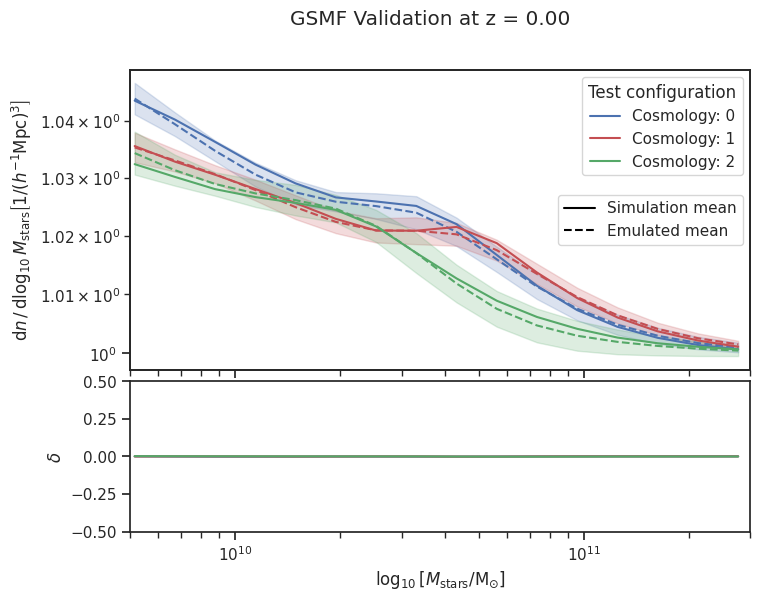

In [8]:
# GSMF validation at z=0 (last snapshot)
input_params = params_test[:3]
target_vals = gsmf_y_vals[test_sim_indices[:3], -1, :]

pred_mean, pred_quant = emulate(gsmf_model_list[-1], input_params)

plt_strings = plot_strings('GSMF')
validation_plot(gsmf_y_ind, target_vals, pred_mean, pred_quant,
                *plt_strings, mlim1, mlim2, 'log', 'log');
plt.suptitle(f'GSMF Validation at z = {z_all[-1]:.2f}')
plt.savefig('../plots/GSMF_multiz_valid.png', bbox_inches='tight')

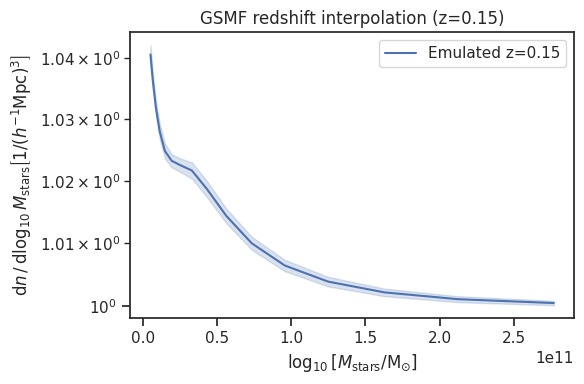

In [9]:
# GSMF redshift interpolation test
test_params = params32[test_sim_indices[0]]
params_with_z = np.append(test_params, [0.15])[np.newaxis, :]
pred_z, pred_z_err = emu_redshift(params_with_z, gsmf_model_list, gsmf_data_list, z_all)

plt.figure(figsize=(6, 4))
plt.plot(gsmf_y_ind, pred_z.flatten(), 'b-', label='Emulated z=0.15')
plt.fill_between(gsmf_y_ind,
                 pred_z.flatten() - pred_z_err.flatten(),
                 pred_z.flatten() + pred_z_err.flatten(),
                 alpha=0.2, color='b')
plt.xlabel(plot_strings('GSMF')[1])
plt.ylabel(plot_strings('GSMF')[2])
plt.yscale('log')
plt.title('GSMF redshift interpolation (z=0.15)')
plt.legend()
plt.tight_layout()

## HMF — Halo Mass Function (11 snapshots)

In [10]:
# Load multi-snapshot HMF data
halo_mass, hmf_arr = read_hmf_all_snaps(DirIn, num_sims, SNAPSHOT_IDS, start_sim_idx=start_sim_idx)
print('halo_mass shape:', halo_mass.shape)
print('hmf_arr shape:', hmf_arr.shape)

# Mass cut
mlim1_hmf, mlim2_hmf = mass_conds('HMF')
mass_cond_hmf = np.where((halo_mass > mlim1_hmf) & (halo_mass < mlim2_hmf))[0]

# NaN interpolation per snapshot
for s in range(hmf_arr.shape[1]):
    hmf_arr[:, s, :] = fill_nan_with_interpolation(hmf_arr[:, s, :], 'linear')

hmf_y_vals = 10**hmf_arr[:, :, mass_cond_hmf]
hmf_y_ind = halo_mass[mass_cond_hmf]
print('hmf_y_vals shape:', hmf_y_vals.shape, '  hmf_y_ind shape:', hmf_y_ind.shape)

halo_mass shape: (49,)
hmf_arr shape: (39, 11, 49)
hmf_y_vals shape: (39, 11, 30)   hmf_y_ind shape: (30,)


In [11]:
# Train / load HMF multi-z emulators
model_dir_hmf = '../models/HMF_multiz/'
z_index_range_hmf = np.arange(len(SNAPSHOT_IDS))  # all 11 snapshots

if do_train:
    os.makedirs(model_dir_hmf, exist_ok=True)
    do_gp_train_multiple(
        model_dir=model_dir_hmf,
        p_train_all=params_train,
        y_vals_all=hmf_y_vals[train_sim_indices],
        y_ind_all=hmf_y_ind,
        z_index_range=z_index_range_hmf,
        exp_variance=exp_variance
    )

# Load all snapshot models
hmf_model_list, hmf_data_list = load_model_multiple(
    model_dir=model_dir_hmf,
    p_train_all=params_train,
    y_vals_all=hmf_y_vals[train_sim_indices],
    y_ind_all=hmf_y_ind,
    z_index_range=z_index_range_hmf,
)
print(f'Loaded {len(hmf_model_list)} HMF models')

Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]]
lamUz
[[5. 5.]]
lamWs
[[100. 100.]]
lamWOs
[[100.]]


Step size tuning: 100%|██████████| 50/50 [00:07<00:00,  6.44it/s]


Done with tune_step_size.
Selected step sizes:
betaU
[[0.2867541  0.35409323]
 [0.00296256 0.02392877]
 [0.00334282 0.01526108]
 [0.00156294 0.03411892]
 [0.00142793 0.02131412]
 [0.00108162 0.0161181 ]
 [0.25945374 0.65036805]
 [0.30851649 0.58259895]]
lamUz
[[2.27131754 2.41164792]]
lamWs
[[5811.93655637  785.25183315]]
lamWOs
[[2741.21270396]]


MCMC sampling: 100%|██████████| 1000/1000 [00:07<00:00, 125.15it/s]


Model saved to ../models/HMF_multiz/multivariate_model_z_index0.pkl
Training complete for snapshot 0
Model saved at ../models/HMF_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]]
lamUz
[[5. 5.]]
lamWs
[[100. 100.]]
lamWOs
[[100.]]


...

Model saved to ../models/HMF_multiz/multivariate_model_z_index9.pkl
Training complete for snapshot 9
Model saved at ../models/HMF_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]]
lamUz
[[5. 5. 5. 5. 5.]]
lamWs
[[100. 100. 100. 100. 100.]]
lamWOs
[[100.]]


Step size tuning: 100%|██████████| 50/50 [00:22<00:00,  2.27it/s]


Done with tune_step_size.
Selected step sizes:
betaU
[[1.16103396e-01 1.74356441e+00 1.08601831e+00 1.43001978e+00
  1.42075675e-01]
 [5.88855887e-02 3.35016881e-01 1.07348820e+00 1.53059668e+01
  5.58545501e-01]
 [1.00324317e-01 1.11898989e+00 5.45116176e-01 9.44183679e-01
  2.80095533e-01]
 [9.43275670e-02 6.57622158e-01 3.44195576e-01 6.56590578e-01
  7.60117385e-01]
 [8.56119636e-03 5.20968368e-02 5.47877837e-02 7.06310248e-02
  8.81178588e-01]
 [9.14358213e-03 4.07300171e-01 7.44712020e-02 4.53782090e-01
  8.01456009e-01]
 [5.87639082e-01 1.65269974e-01 2.85051366e-01 1.63782489e-01
  4.76514497e-01]
 [3.77246036e-02 7.04442983e-01 2.39405271e-01 3.32759982e-02
  1.51208411e+00]]
lamUz
[[2.24263644 1.70773396 1.30375822 1.92280536 1.42432513]]
lamWs
[[2850.45298565 4144.23783446 3819.94842776 4466.85094281 5159.7998405 ]]
lamWOs
[[1171.50720173]]


MCMC sampling: 100%|██████████| 1000/1000 [00:19<00:00, 51.83it/s]

Model saved to ../models/HMF_multiz/multivariate_model_z_index10.pkl
Training complete for snapshot 10
Model saved at ../models/HMF_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Number of models loaded: 11 from: ../models/HMF_multiz/
Loaded 11 HMF models


Maximum relative error (mean): 0.0023 (0.23%)
Mean relative error (mean): 0.0003 (0.03%)
Maximum relative error (quantiles): 0.0071 (0.71%)
Mean relative error (quantiles): 0.0012 (0.12%)
0.997141635329747 1.0597541705261755


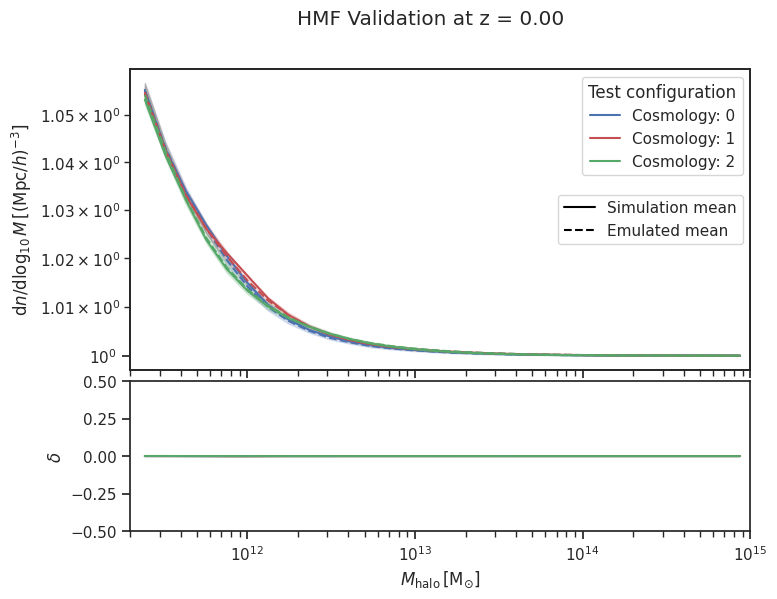

In [12]:
# HMF validation at z=0
input_params_hmf = params_test[:3]
target_vals_hmf = hmf_y_vals[test_sim_indices[:3], -1, :]

pred_mean_hmf, pred_quant_hmf = emulate(hmf_model_list[-1], input_params_hmf)

plt_strings_hmf = plot_strings('HMF')
validation_plot(hmf_y_ind, target_vals_hmf, pred_mean_hmf, pred_quant_hmf,
                *plt_strings_hmf, mlim1_hmf, mlim2_hmf, 'log', 'log');
plt.suptitle(f'HMF Validation at z = {z_all[-1]:.2f}')
plt.savefig('../plots/HMF_multiz_valid.png', bbox_inches='tight')

## fGas — Cluster Gas Fraction (7 snapshots, z ≤ 1.0)

In [13]:
# Load multi-snapshot fGas data
log_halo_mass, fgas_arr = read_gasfr_all_snaps(DirIn, num_sims, SNAPSHOT_IDS, start_sim_idx=start_sim_idx)
print('log_halo_mass shape:', log_halo_mass.shape)
print('fgas_arr shape:', fgas_arr.shape)

# Mass cut. mass_conds('fGas') returns linear mass limits (10**13.5, 10**14.3),
# while log_halo_mass is in log10 units — exponentiate before comparing.
mlim1_fg, mlim2_fg = mass_conds('fGas')
mass_cond_fg = np.where((10**log_halo_mass > mlim1_fg) & (10**log_halo_mass < mlim2_fg))[0]

# NaN interpolation per snapshot (cubic for fGas)
for s in range(fgas_arr.shape[1]):
    fgas_arr[:, s, :] = fill_nan_with_interpolation(fgas_arr[:, s, :], 'cubic')

fgas_y_vals = fgas_arr[:, :, mass_cond_fg]
fgas_y_ind = 10**log_halo_mass[mass_cond_fg]
print('fgas_y_vals shape:', fgas_y_vals.shape, '  fgas_y_ind shape:', fgas_y_ind.shape)

log_halo_mass shape: (20,)
fgas_arr shape: (39, 11, 20)
fgas_y_vals shape: (39, 11, 3)   fgas_y_ind shape: (3,)


In [14]:
# Train / load fGas multi-z emulators (only snapshots 4-10, z <= 1.0)
model_dir_fg = '../models/fGas_multiz/'
z_index_range_fg = np.arange(4, 11)  # 7 valid snapshots

fgas_z_all = z_all[z_index_range_fg]
print(f'fGas valid snapshots: {len(z_index_range_fg)}, z range: [{fgas_z_all.min():.3f}, {fgas_z_all.max():.3f}]')

if do_train:
    os.makedirs(model_dir_fg, exist_ok=True)
    do_gp_train_multiple(
        model_dir=model_dir_fg,
        p_train_all=params_train,
        y_vals_all=fgas_y_vals[train_sim_indices],
        y_ind_all=fgas_y_ind,
        z_index_range=z_index_range_fg,
        exp_variance=exp_variance
    )

# Load all snapshot models
fgas_model_list, fgas_data_list = load_model_multiple(
    model_dir=model_dir_fg,
    p_train_all=params_train,
    y_vals_all=fgas_y_vals[train_sim_indices],
    y_ind_all=fgas_y_ind,
    z_index_range=z_index_range_fg,
)
print(f'Loaded {len(fgas_model_list)} fGas models')

fGas valid snapshots: 7, z range: [0.000, 1.000]
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]]
lamUz
[[5. 5. 5.]]
lamWs
[[100. 100. 100.]]
lamWOs
[[100.]]


Step size tuning: 100%|██████████| 50/50 [00:13<00:00,  3.81it/s]


Done with tune_step_size.
Selected step sizes:
betaU
[[1.49268168 1.24420017 1.78807498]
 [0.03435473 0.06901283 0.88960593]
 [0.11990989 0.41892898 0.35074765]
 [0.18107554 0.43261655 0.04231855]
 [0.3097004  1.96881366 0.16775492]
 [0.79445032 0.96602396 0.09139638]
 [1.63496213 0.71216236 2.28680656]
 [0.0607069  0.13561787 1.21377625]]
lamUz
[[1.81022289 1.90400979 2.42927339]]
lamWs
[[4348.36652911 4480.15017024 4351.09582031]]
lamWOs
[[2826.39464565]]


MCMC sampling: 100%|██████████| 1000/1000 [00:11<00:00, 87.53it/s]


Model saved to ../models/fGas_multiz/multivariate_model_z_index4.pkl
Training complete for snapshot 4
Model saved at ../models/fGas_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]]
lamUz
[[5. 5. 5.]]
lamWs
[[100. 100. 100.]]
lamWOs
[[100.]]


...

Model saved to ../models/fGas_multiz/multivariate_model_z_index9.pkl
Training complete for snapshot 9
Model saved at ../models/fGas_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]]
lamUz
[[5. 5. 5.]]
lamWs
[[100. 100. 100.]]
lamWOs
[[100.]]


Step size tuning: 100%|██████████| 50/50 [00:12<00:00,  4.00it/s]


Done with tune_step_size.
Selected step sizes:
betaU
[[1.38532601 0.37011754 0.17826489]
 [0.05378279 0.25690186 0.41661399]
 [0.05184671 0.03274156 2.98925993]
 [0.04333244 0.28891    0.1878531 ]
 [0.52630362 0.46847961 1.25215294]
 [0.75296025 0.59410062 0.46312414]
 [1.19277774 0.61974866 0.19516753]
 [0.07328671 0.03096957 3.39166607]]
lamUz
[[1.27748277 1.76349904 2.69957813]]
lamWs
[[4083.77502945 4121.45767705 4359.6190234 ]]
lamWOs
[[2126.64903469]]


MCMC sampling: 100%|██████████| 1000/1000 [00:11<00:00, 90.38it/s]

Model saved to ../models/fGas_multiz/multivariate_model_z_index10.pkl
Training complete for snapshot 10
Model saved at ../models/fGas_multiz/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Number of models loaded: 7 from: ../models/fGas_multiz/
Loaded 7 fGas models


Maximum relative error (mean): 0.4260 (42.60%)
Mean relative error (mean): 0.1511 (15.11%)
Maximum relative error (quantiles): 0.5033 (50.33%)
Mean relative error (quantiles): 0.2230 (22.30%)
0.06409824086820891 0.17819102710871712


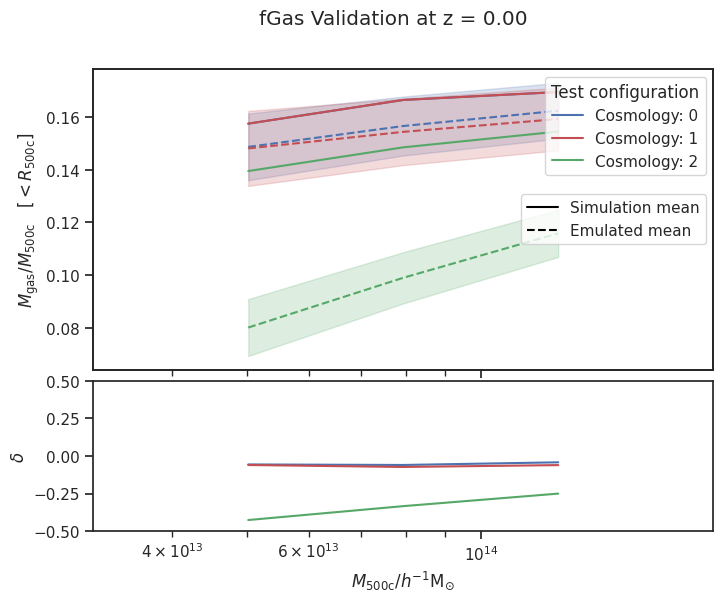

In [15]:
# fGas validation at z=0 (last snapshot in valid range)
input_params_fg = params_test[:3]
target_vals_fg = fgas_y_vals[test_sim_indices[:3], -1, :]

pred_mean_fg, pred_quant_fg = emulate(fgas_model_list[-1], input_params_fg)

plt_strings_fg = plot_strings('fGas')
validation_plot(fgas_y_ind, target_vals_fg, pred_mean_fg, pred_quant_fg,
                *plt_strings_fg, mlim1_fg, mlim2_fg, 'log', 'linear');
plt.suptitle(f'fGas Validation at z = {z_all[-1]:.2f}')
plt.savefig('../plots/fGas_multiz_valid.png', bbox_inches='tight')

## Pk — Power Spectrum Suppression (z=0 only)

In [16]:
# Load Pk data (z=0 only)
k, pk_arr, pk_go_arr, pk_ratio = read_pk_new(
    DirIn_pk, num_sims, redshift='0.0', pk_type='hydro.full', start_sim_idx=start_sim_idx
)
print('k shape:', k.shape)
print('pk_ratio shape:', pk_ratio.shape)

# k-range cut
mlim1_pk, mlim2_pk = mass_conds('Pk')
k_cond = np.where((k > mlim1_pk) & (k < mlim2_pk))[0]

pk_y_vals = pk_ratio[:, k_cond]
pk_y_ind = k[k_cond]
print('pk_y_vals shape:', pk_y_vals.shape, '  pk_y_ind shape:', pk_y_ind.shape)

k shape: (1385,)
pk_ratio shape: (39, 1385)
pk_y_vals shape: (39, 511)   pk_y_ind shape: (511,)


Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1]
 [0.1]
 [0.1]
 [0.1]
 [0.1]
 [0.1]
 [0.1]
 [0.1]]
lamUz
[[5.]]
lamWs
[[100.]]
lamWOs
[[100.]]


Step size tuning:   0%|          | 0/50 [00:00<?, ?it/s]

Step size tuning: 100%|██████████| 50/50 [00:04<00:00, 10.96it/s]


Done with tune_step_size.
Selected step sizes:
betaU
[[1.51940707]
 [0.4222849 ]
 [0.12047905]
 [0.12649443]
 [0.45679536]
 [1.01682647]
 [0.22844274]
 [0.06268556]]
lamUz
[[1.55221224]]
lamWs
[[4619.39612438]]
lamWOs
[[8.41194887]]


MCMC sampling: 100%|██████████| 1000/1000 [00:04<00:00, 245.46it/s]


Model saved to ../models/Pk_multivariate_model_z_index0.pkl
No thetas to plot


(None, <Figure size 1000x750 with 5 Axes>)

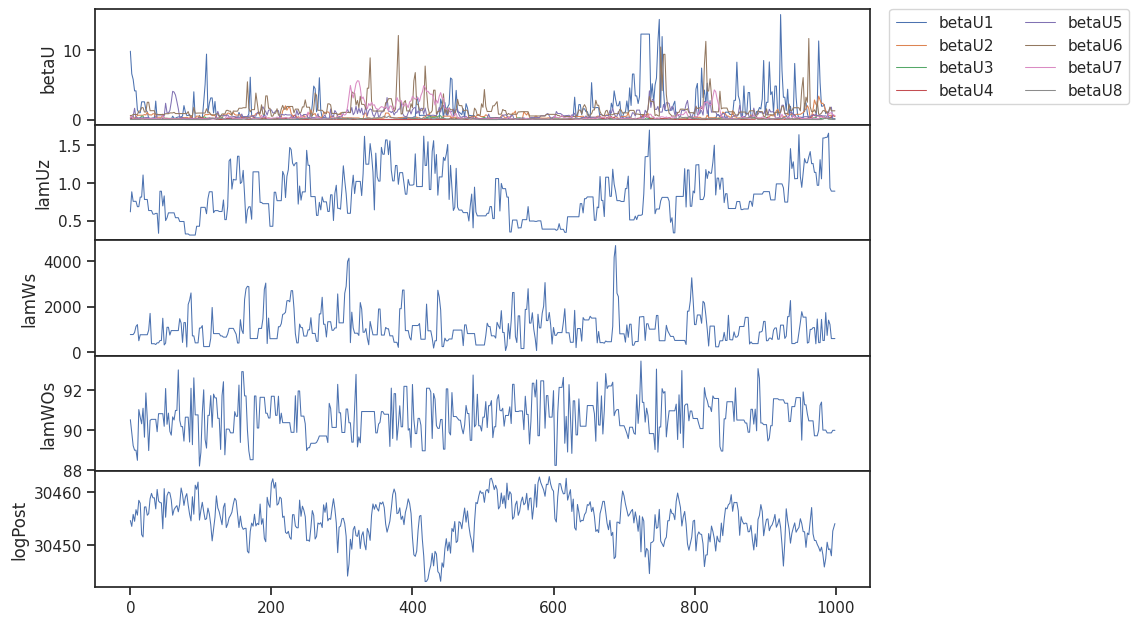

In [17]:
# Train / load Pk emulator (single z=0, exp_variance=0.95)
z_index = 0
model_filename_pk = '../models/Pk_multivariate_model_z_index' + str(z_index)

p_all_train_pk = params32[train_sim_indices]
pk_y_vals_train = pk_y_vals[train_sim_indices]

sepia_data_pk = sepia_data_format(p_all_train_pk, pk_y_vals_train, pk_y_ind)
sepia_model_pk = do_pca(sepia_data_pk, exp_variance=0.95)

if do_train:
    sepia_model_pk = do_gp_train(sepia_model_pk, model_filename_pk)

sepia_model_pk = gp_load(sepia_model_pk, model_filename_pk)
plot_train_diagnostics(sepia_model_pk)

Maximum relative error (mean): 0.1006 (10.06%)
Mean relative error (mean): 0.0432 (4.32%)
Maximum relative error (quantiles): 0.1806 (18.06%)
Mean relative error (quantiles): 0.0993 (9.93%)
0.7102067760811512 1.025785538349577


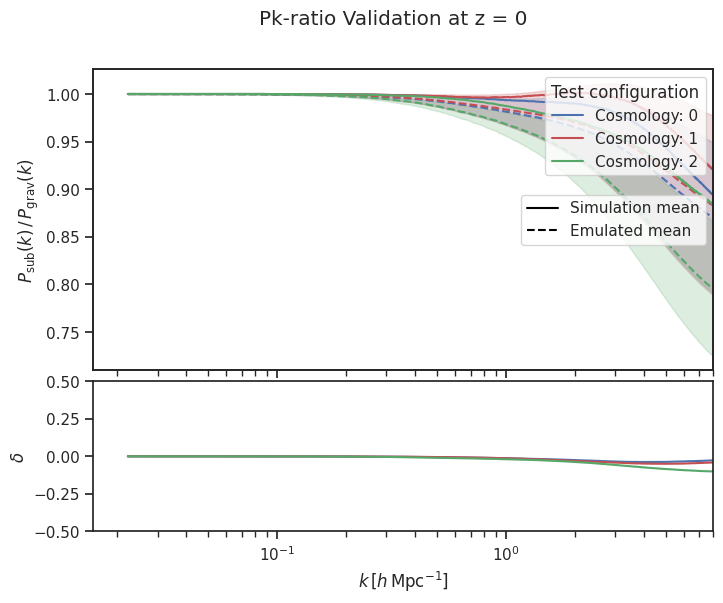

In [18]:
# Pk validation at z=0
input_params_pk = params_test[:3]
target_vals_pk = pk_y_vals[test_sim_indices[:3]]

pred_mean_pk, pred_quant_pk = emulate(sepia_model_pk, input_params_pk)

plt_strings_pk = plot_strings('Pk')
validation_plot(pk_y_ind, target_vals_pk, pred_mean_pk, pred_quant_pk,
                *plt_strings_pk, mlim1_pk, mlim2_pk, 'log', 'linear');
plt.suptitle('Pk-ratio Validation at z = 0')
plt.savefig('../plots/Pk_valid.png', bbox_inches='tight')

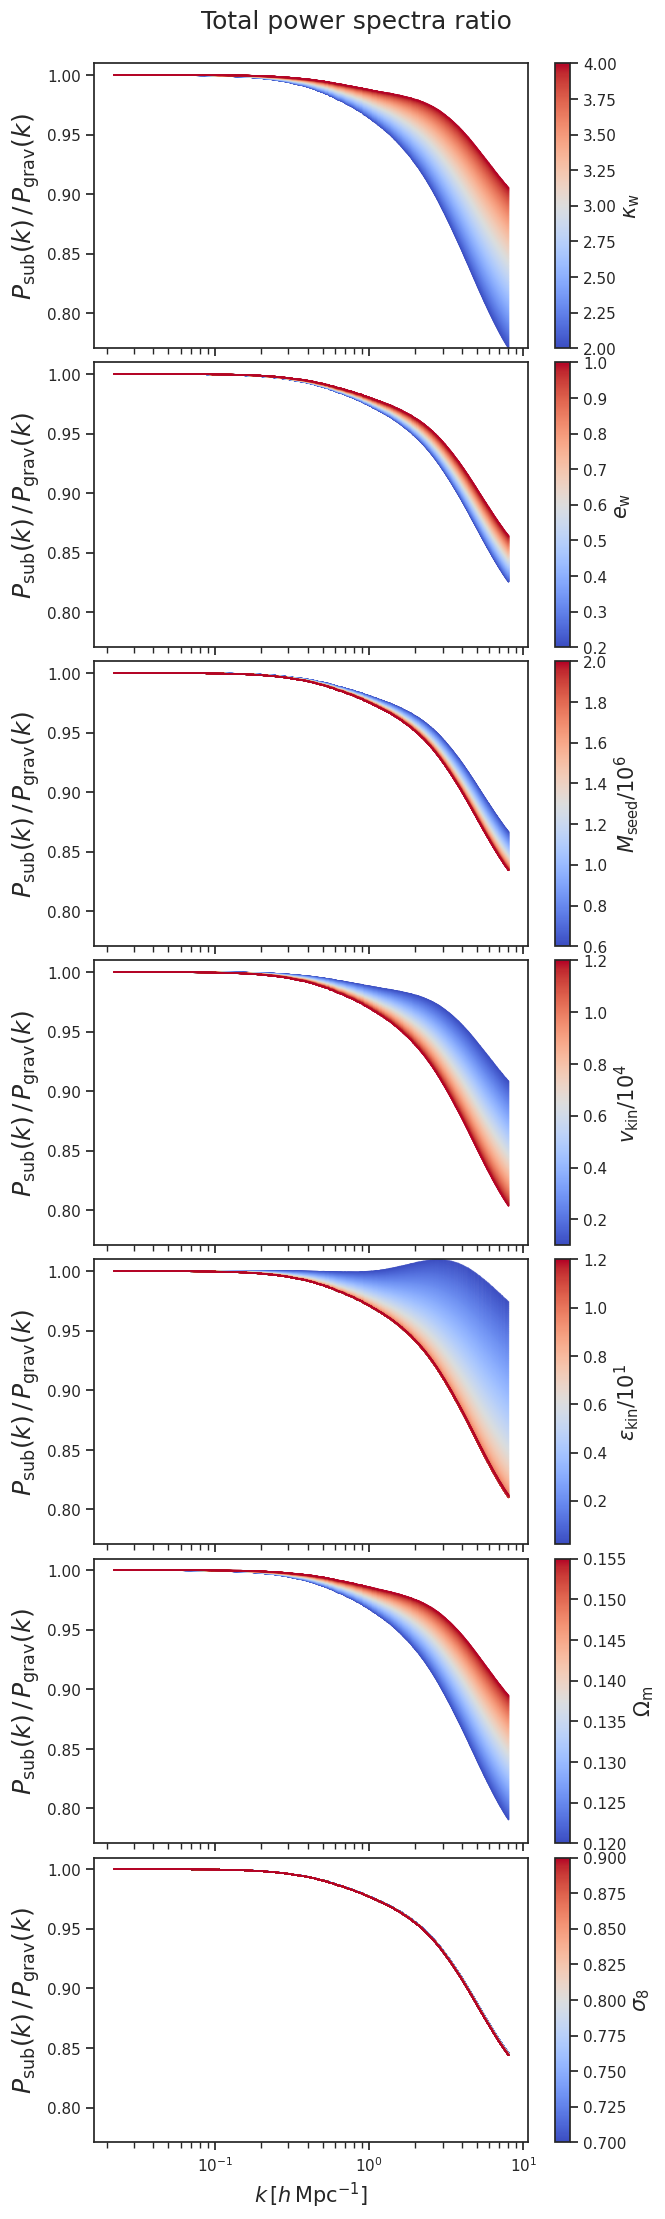

In [19]:
# Pk sensitivity
f = sensitivity_plot(pk_y_ind, params32, sepia_model_pk, emulate, PARAM_NAME,
                     *plt_strings_pk, mlim1_pk, mlim2_pk, 'log', 'linear')
plt.savefig('../plots/Pk_sensi.png', bbox_inches='tight')

## Extra summary plots (ported from `_old/gp_SGC_all_multiz.ipynb` and `_old/gp_SGC_pk.ipynb`)

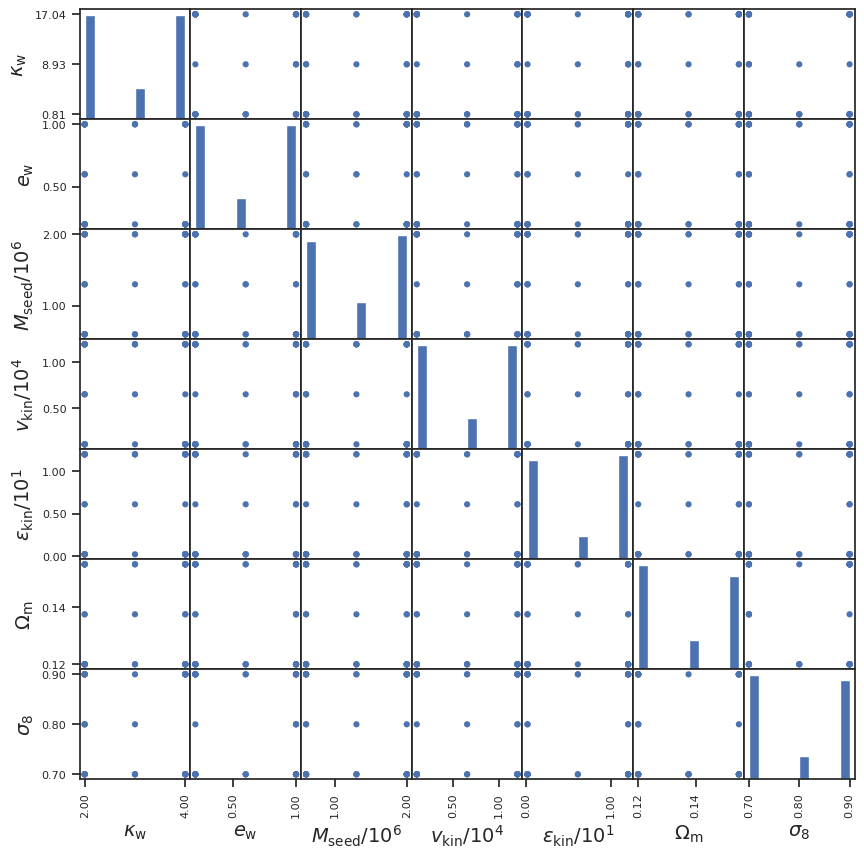

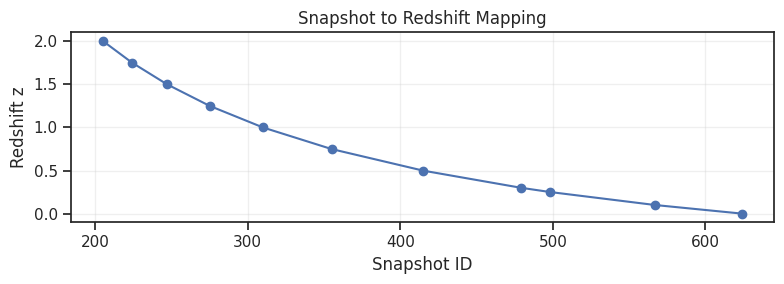

In [20]:
# exp_design.png  +  exp_design_pk.png — design-space scatter matrix
df_design = pd.DataFrame(params32, columns=PARAM_NAME)
plot_scatter_matrix(df_design, ['b'] * params32.shape[0]);
plt.savefig('../plots/exp_design.png', bbox_inches='tight')
plt.savefig('../plots/exp_design_pk.png', bbox_inches='tight')
plt.show()

# snapshot_z.png — redshift mapping of available snapshots
plt.figure(figsize=(8, 3))
plt.plot(SNAPSHOT_IDS, z_all, 'o-')
plt.xlabel('Snapshot ID'); plt.ylabel('Redshift z')
plt.title('Snapshot to Redshift Mapping')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/snapshot_z.png', bbox_inches='tight')
plt.show()

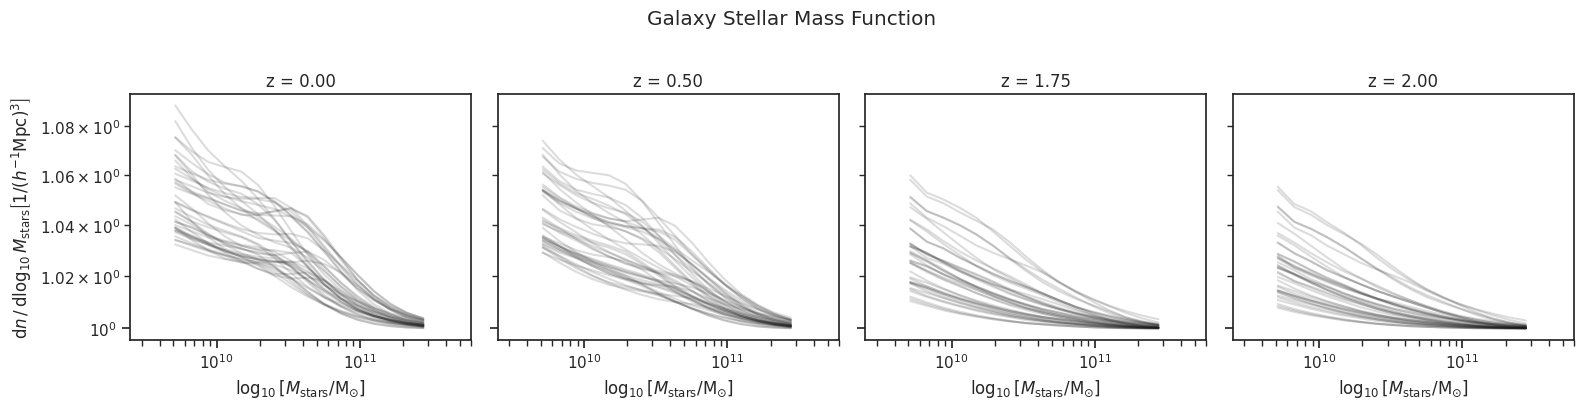

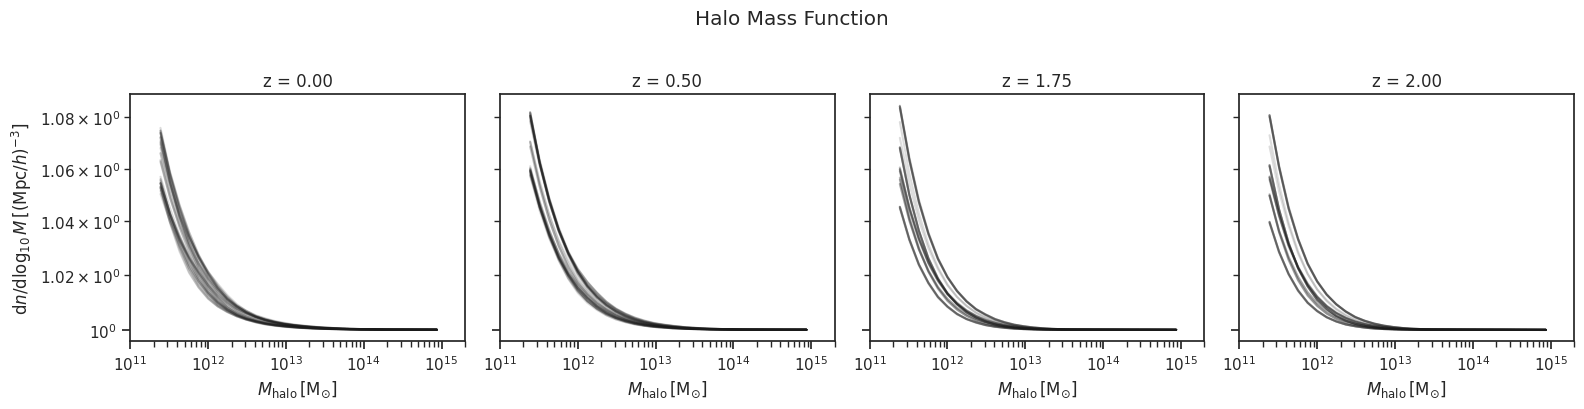

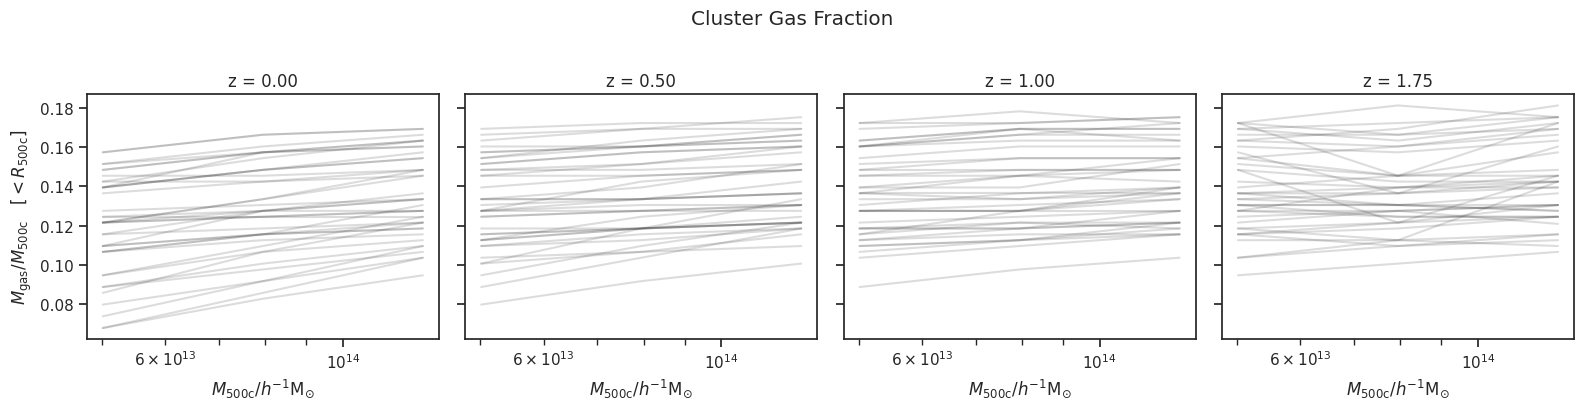

In [21]:
# GSMF_multiz.png / HMF_multiz.png / fGas_multiz.png — sim ensemble at multiple z
import matplotlib.pyplot as plt

# --- GSMF ---
snap_indices_to_plot = [-1, -5, -10, 0]
plt_strings = plot_strings('GSMF')
mlim1, mlim2 = mass_conds('GSMF')
gsmf_mask = (stellar_mass > mlim1) & (stellar_mass < mlim2)
fig, axes = plt.subplots(1, len(snap_indices_to_plot),
                         figsize=(4*len(snap_indices_to_plot), 4), sharey=True)
for i, snap_idx in enumerate(snap_indices_to_plot):
    ax = axes[i]; z_snap = z_all[snap_idx]
    for sim_i in range(num_sims):
        ax.plot(stellar_mass[gsmf_mask], gsmf_y_vals[sim_i, snap_idx, :],
                'k-', alpha=0.15)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f'z = {z_snap:.2f}'); ax.set_xlabel(plt_strings[1])
    if i == 0: ax.set_ylabel(plt_strings[2])
    ax.set_xlim(0.5*mlim1, 2*mlim2)
plt.suptitle('Galaxy Stellar Mass Function', y=1.02); plt.tight_layout()
plt.savefig('../plots/GSMF_multiz.png', bbox_inches='tight'); plt.show()

# --- HMF ---
plt_strings_hmf = plot_strings('HMF')
hmf_mask = (halo_mass > mlim1_hmf) & (halo_mass < mlim2_hmf)
fig, axes = plt.subplots(1, len(snap_indices_to_plot),
                         figsize=(4*len(snap_indices_to_plot), 4), sharey=True)
for i, snap_idx in enumerate(snap_indices_to_plot):
    ax = axes[i]; z_snap = z_all[snap_idx]
    for sim_i in range(num_sims):
        ax.plot(halo_mass[hmf_mask], hmf_y_vals[sim_i, snap_idx, :],
                'k-', alpha=0.15)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f'z = {z_snap:.2f}'); ax.set_xlabel(plt_strings_hmf[1])
    if i == 0: ax.set_ylabel(plt_strings_hmf[2])
    ax.set_xlim(0.5*mlim1_hmf, 2*mlim2_hmf)
plt.suptitle('Halo Mass Function', y=1.02); plt.tight_layout()
plt.savefig('../plots/HMF_multiz.png', bbox_inches='tight'); plt.show()

# --- fGas ---
fgas_snap_indices = [-1, -5, -7, -10]
plt_strings_fgas = plot_strings('fGas')
fig, axes = plt.subplots(1, len(fgas_snap_indices),
                         figsize=(4*len(fgas_snap_indices), 4), sharey=True)
for i, snap_idx in enumerate(fgas_snap_indices):
    ax = axes[i]; z_snap = z_all[snap_idx]
    for sim_i in range(num_sims):
        ax.plot(fgas_y_ind, fgas_y_vals[sim_i, snap_idx, :], 'k-', alpha=0.15)
    ax.set_xscale('log')
    ax.set_title(f'z = {z_snap:.2f}'); ax.set_xlabel(plt_strings_fgas[1])
    if i == 0: ax.set_ylabel(plt_strings_fgas[2])
plt.suptitle('Cluster Gas Fraction', y=1.02); plt.tight_layout()
plt.savefig('../plots/fGas_multiz.png', bbox_inches='tight'); plt.show()

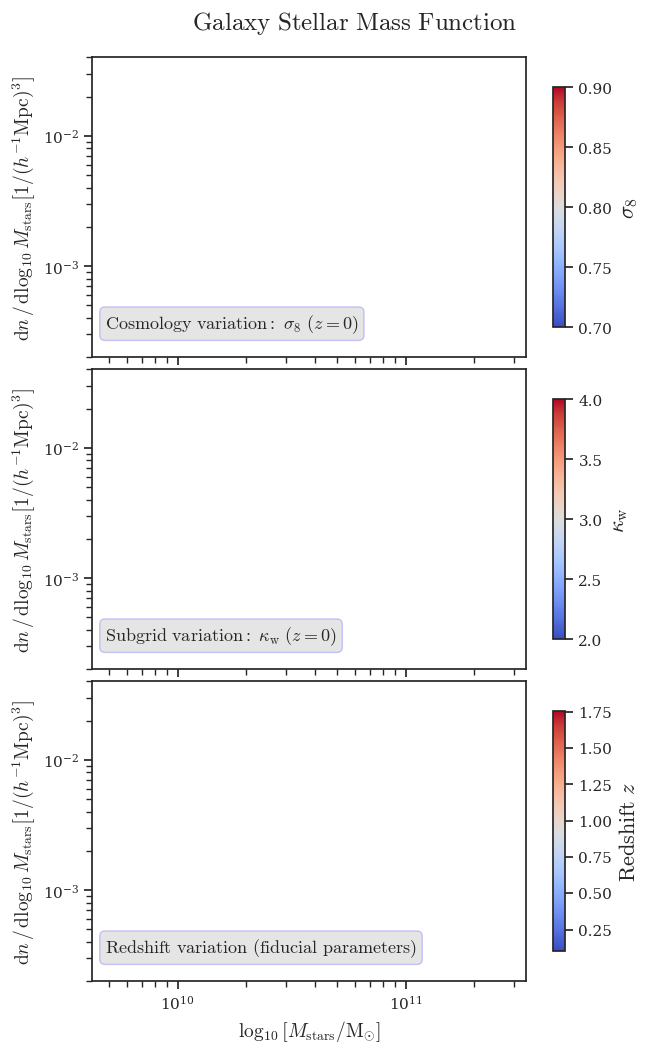

In [27]:
# GSMF_sensi_multiz.png — sigma_8 vs kappa_w vs redshift, 3-panel
import matplotlib.colors as mcolors
import matplotlib.cm as cm


plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'

numPlots = 300
allMax  = np.max(params32, axis=0)
allMin  = np.min(params32, axis=0)
allMean = np.mean(params32, axis=0)

plt_strings = plot_strings('GSMF')
mlim1, mlim2 = mass_conds('GSMF')
cmap = cm.coolwarm
bbox_props = dict(boxstyle='round,pad=0.3', facecolor='grey',
                  alpha=0.2, edgecolor='blue')

fig, axes = plt.subplots(3, 1, figsize=(7, 12), sharex=True)
plt.subplots_adjust(hspace=0.04)

def _panel(ax, model, param_idx_or_z, mode, label):
    if mode == 'param':
        paramNo = param_idx_or_z
        rng = np.linspace(allMin[paramNo], allMax[paramNo], numPlots)
        norm = mcolors.Normalize(vmin=allMin[paramNo], vmax=allMax[paramNo])
        for v in rng:
            p = np.copy(allMean); p[paramNo] = v
            pred, _ = emulate(model, p)
            ax.plot(gsmf_y_ind, pred.flatten(), lw=1,
                    color=cmap(norm(v)), alpha=0.7)
        cbar_label = PARAM_NAME[paramNo]
    else:  # 'z'
        z_grid = param_idx_or_z
        norm = mcolors.Normalize(vmin=z_grid.min(), vmax=z_grid.max())
        for zv in z_grid:
            p_with_z = np.hstack([allMean.reshape(1, -1), np.array([[zv]])])
            pred, _ = emu_redshift(p_with_z, gsmf_model_list, gsmf_data_list, z_all)
            ax.plot(gsmf_y_ind, pred.flatten(), lw=1,
                    color=cmap(norm(zv)), alpha=0.7)
        cbar_label = r'$\mathrm{Redshift}\ z$'
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_ylabel(plt_strings[2], fontsize=14)
    ax.set_ylim(2e-4, 4e-2)
    ax.fill_between(gsmf_y_ind, 9e-5*0.8, 1e-1*1.2,
                    where=(gsmf_y_ind < mlim1), color='k', alpha=0.1)
    ax.fill_between(gsmf_y_ind, 9e-5*0.8, 1e-1*1.2,
                    where=(gsmf_y_ind > mlim2), color='k', alpha=0.1)
    sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
    cbar.set_label(cbar_label, fontsize=16)
    ax.text(0.03, 0.15, label, transform=ax.transAxes,
            fontsize=13, verticalalignment='top', bbox=bbox_props)

_panel(axes[0], gsmf_model_list[-1], 6, 'param',
       r'$\mathrm{Cosmology\ variation:}\ \sigma_8\ (z=0)$')
_panel(axes[1], gsmf_model_list[-1], 0, 'param',
       r'$\mathrm{Subgrid\ variation:}\ \kappa_\mathrm{w}\ (z=0)$')
z_grid = np.linspace(z_all[-2], z_all[1], numPlots)
_panel(axes[2], None, z_grid, 'z',
       r'$\mathrm{Redshift\ variation\ (fiducial\ parameters)}$')
axes[2].set_xlabel(plt_strings[1], fontsize=14)

plt.suptitle(r'$\mathrm{Galaxy\ Stellar\ Mass\ Function}$', fontsize=18, y=0.92)
plt.savefig('../plots/GSMF_sensi_multiz.png', bbox_inches='tight')
plt.show()

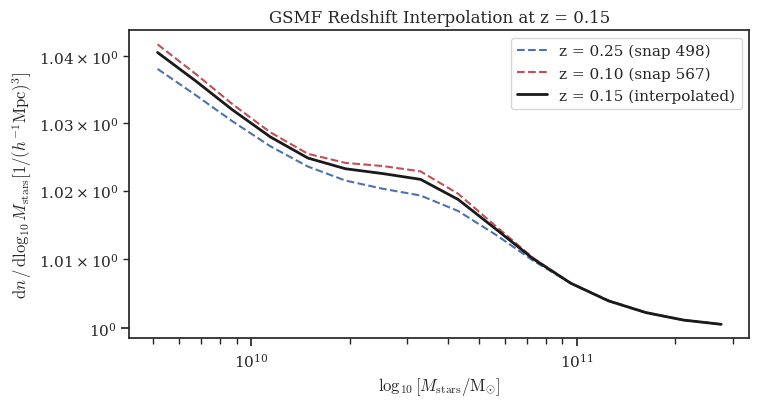

In [24]:
# GSMF_z_interp.png — visualize redshift interpolation for one test sim
z_interp = 0.15  # between snapshot 567 (z≈0.10) and 498 (z≈0.25)

test_param = params_test[0:1]
input_with_z = np.hstack([test_param, np.array([[z_interp]])])
pred_interp, pred_interp_err = emu_redshift(
    input_params_and_redshift=input_with_z,
    sepia_model_list=gsmf_model_list,
    sepia_data_list=gsmf_data_list,
    z_all=z_all,
)

# Bracketing snapshots
snap_lo = np.where(z_all >= z_interp)[0][-1]
snap_hi = snap_lo + 1
pred_lo, _ = emulate(gsmf_model_list[snap_lo], test_param)
pred_hi, _ = emulate(gsmf_model_list[snap_hi], test_param)

plt.figure(figsize=(8, 4))
plt.plot(gsmf_y_ind, pred_lo.flatten(), 'b--',
         label=f'z = {z_all[snap_lo]:.2f} (snap {SNAPSHOT_IDS[snap_lo]})')
plt.plot(gsmf_y_ind, pred_hi.flatten(), 'r--',
         label=f'z = {z_all[snap_hi]:.2f} (snap {SNAPSHOT_IDS[snap_hi]})')
plt.plot(gsmf_y_ind, pred_interp.flatten(), 'k-', lw=2,
         label=f'z = {z_interp:.2f} (interpolated)')
plt.xscale('log'); plt.yscale('log')
plt.xlabel(plot_strings('GSMF')[1]); plt.ylabel(plot_strings('GSMF')[2])
plt.title(f'GSMF Redshift Interpolation at z = {z_interp}')
plt.legend()
plt.savefig('../plots/GSMF_z_interp.png', bbox_inches='tight')
plt.show()

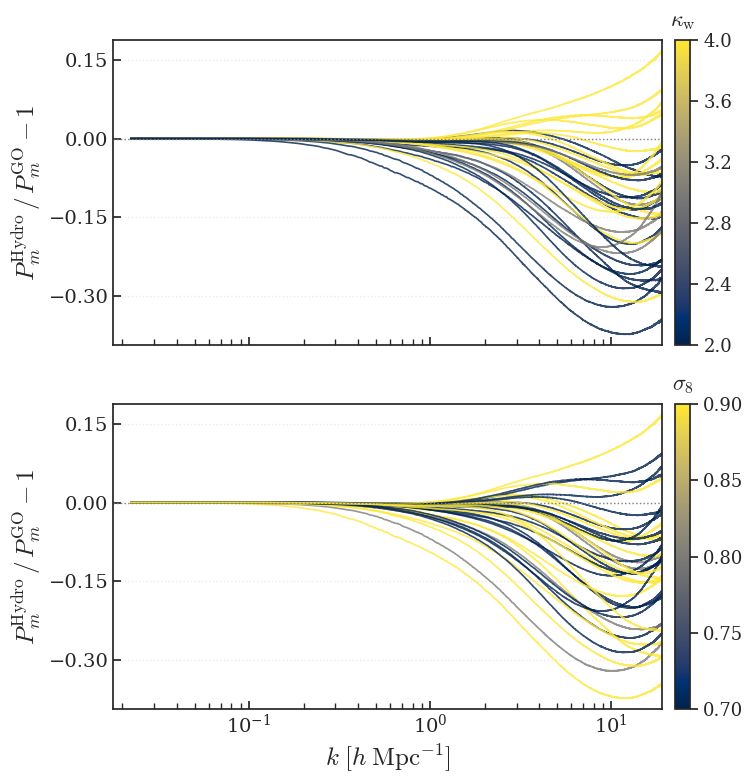

In [25]:
# Pk_design.png — Pk-suppression (Pk_hydro/Pk_GO - 1) colored by two design params
import matplotlib as mpl

color_index_top    = 0    # kappa_w
color_index_bottom = 6    # sigma_8

plt_strings_pk_d = plot_strings('Pk')
mlim1_pkd, mlim2_pkd = mass_conds('Pk')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
pk_suppression = pk_ratio - 1.0

k_xlim = 19.0
k_mask = k < k_xlim
y_min  = pk_suppression[:, k_mask].min()
y_max  = pk_suppression[:, k_mask].max()
y_pad  = 0.02

for ax, ci in [(ax1, color_index_top), (ax2, color_index_bottom)]:
    norm = mpl.colors.Normalize(vmin=params32[:, ci].min(),
                                vmax=params32[:, ci].max())
    cmap_obj = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.cividis)
    cmap_obj.set_array([])
    for sim_index in range(num_sims):
        ax.plot(k, pk_suppression[sim_index], '-', alpha=0.8, lw=1.2,
                c=cmap_obj.to_rgba(params32[sim_index, ci]))
    ax.axhline(y=0.0, ls=':', color='gray', lw=1.0)
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='major', labelsize=14, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=11, direction='in')
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=4))
    ax.grid(axis='y', ls=':', alpha=0.4)
    ax.set_xlim(k.min() * 0.8, k_xlim)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.set_ylabel(r'$P_m^{\mathrm{Hydro}} \, / \, P_m^{\mathrm{GO}} - 1$', fontsize=18)
    clb = fig.colorbar(cmap_obj, ax=ax, pad=0.02)
    clb.ax.tick_params(labelsize=13)
    clb.ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=5))
    clb.ax.set_title(PARAM_NAME[ci], fontsize=16, pad=10)

ax2.set_xlabel(r'$k \; [h \; \mathrm{Mpc}^{-1}]$', fontsize=18)
fig.tight_layout()
plt.savefig('../plots/Pk_design.png', bbox_inches='tight', dpi=150)
plt.show()

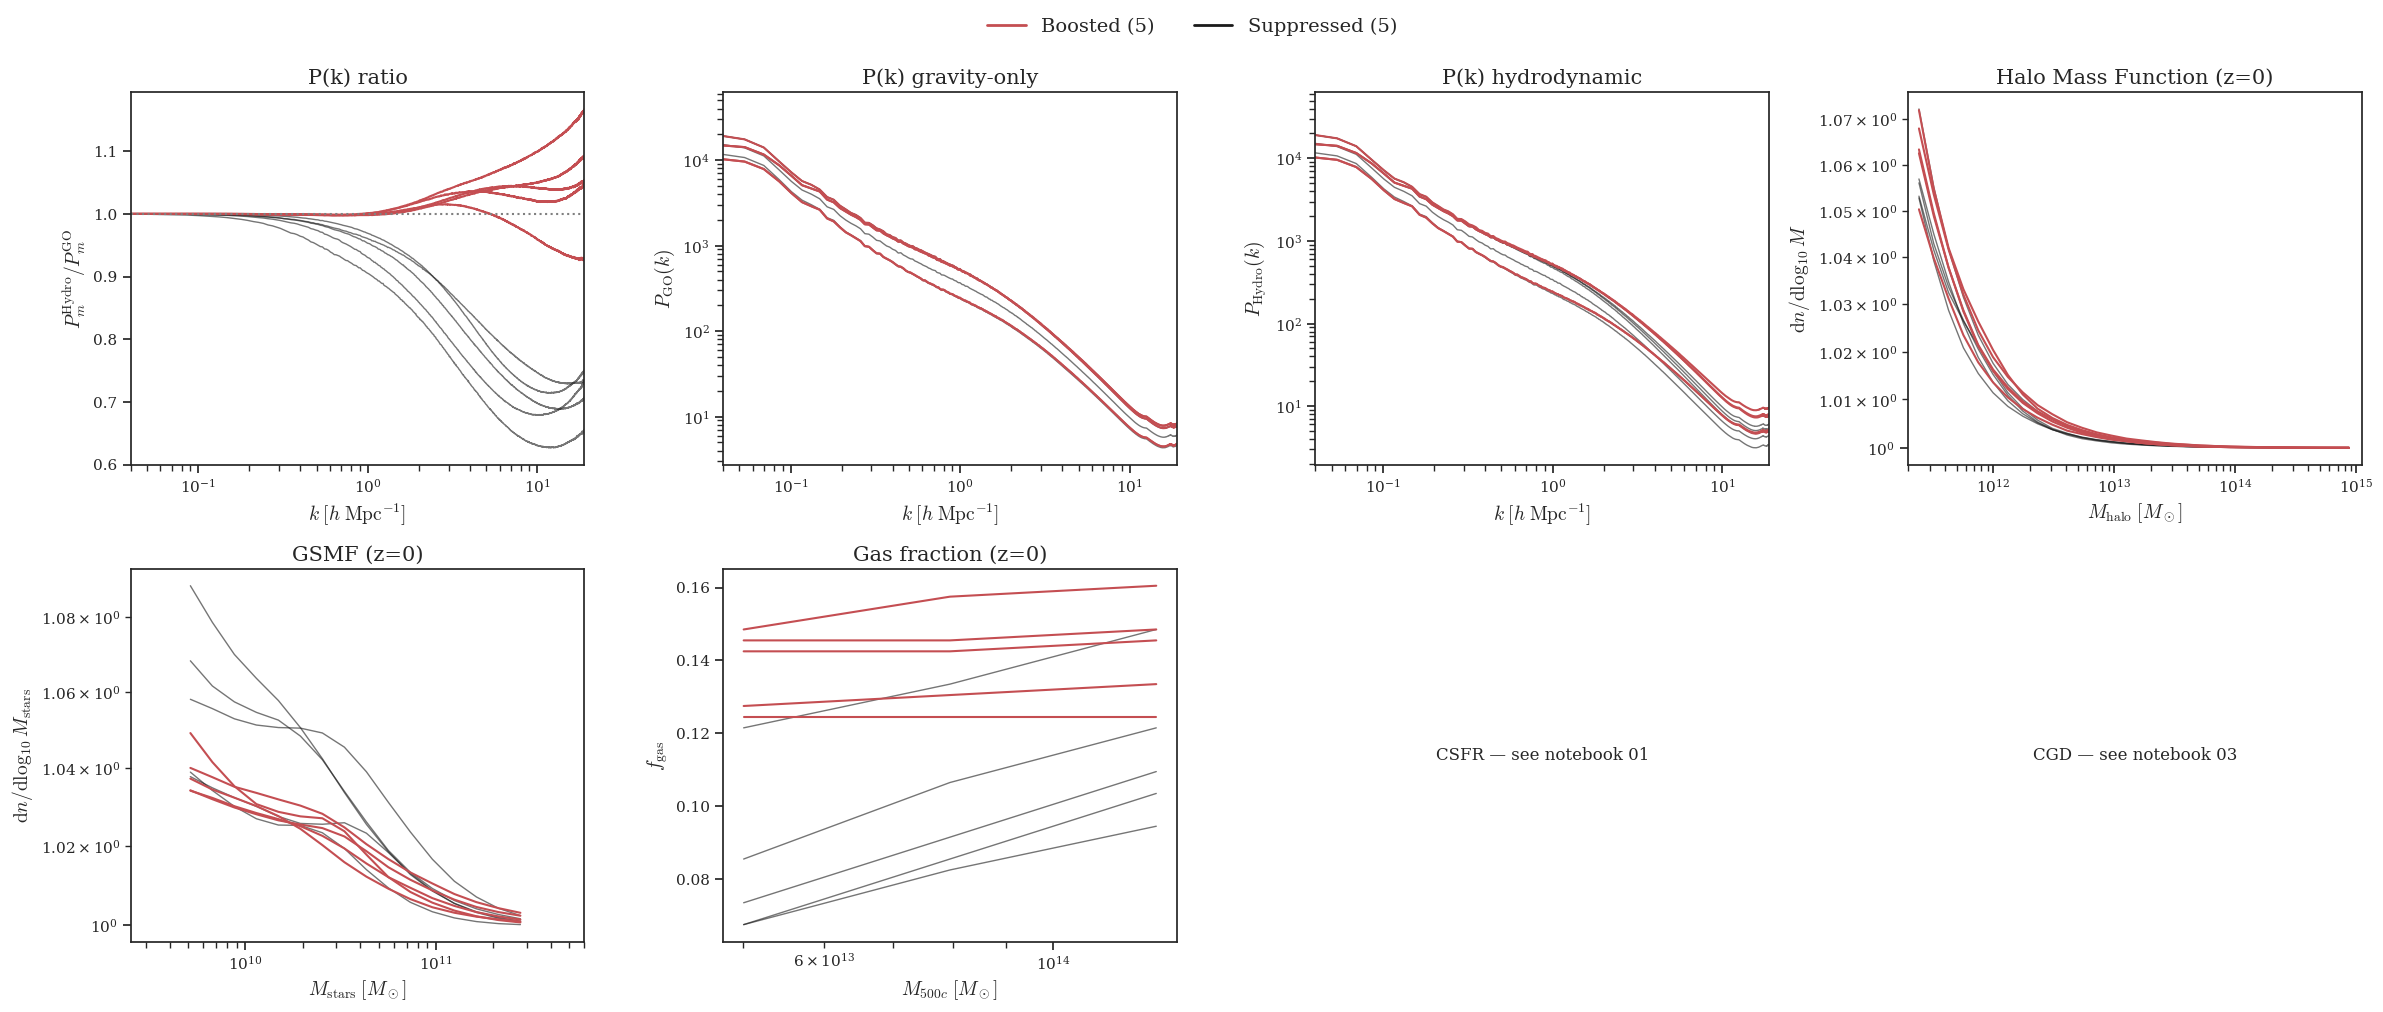

In [26]:
# Pk_boosted_vs_suppressed_4x2.png — sims with most boosted vs most suppressed Pk
# Note: CSFR (in nb #01) and CGD (in nb #03) overlays are omitted here; those
# slots are hidden. Obs overlays are also skipped to avoid hard-coded data paths.
from matplotlib.lines import Line2D

# Pick boosted/suppressed sims by P(k) ratio at a non-linear k
k_ref_idx = int(np.argmin(np.abs(k - 1.0)))  # k ~ 1 h/Mpc
order = np.argsort(pk_ratio[:, k_ref_idx])
suppressed_idx = order[:5].tolist()
boosted_idx    = order[-5:].tolist()

k_xlim1, k_xlim2 = 0.04, 19.0
k_mask_plot = k < k_xlim2

fig, axes = plt.subplots(2, 4, figsize=(24, 10))

# (0,0) P(k) ratio
ax = axes[0, 0]
for i in suppressed_idx:
    ax.plot(k[k_mask_plot], pk_ratio[i, k_mask_plot], '-', color='k', alpha=0.6, lw=1)
for i in boosted_idx:
    ax.plot(k[k_mask_plot], pk_ratio[i, k_mask_plot], '-', color='r', alpha=1, lw=1.5)
ax.axhline(y=1.0, ls=':', color='gray'); ax.set_xscale('log')
ax.set_xlim(k_xlim1, k_xlim2)
ax.set_xlabel(r'$k \; [h \; \mathrm{Mpc}^{-1}]$', fontsize=14)
ax.set_ylabel(r'$P_m^{\mathrm{Hydro}} / P_m^{\mathrm{GO}}$', fontsize=14)
ax.set_title('P(k) ratio', fontsize=15)

# (0,1) P(k) GO
ax = axes[0, 1]
for i in suppressed_idx:
    ax.plot(k[k_mask_plot], pk_go_arr[i, k_mask_plot], '-', color='k', alpha=0.6, lw=1)
for i in boosted_idx:
    ax.plot(k[k_mask_plot], pk_go_arr[i, k_mask_plot], '-', color='r', alpha=1, lw=1.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(k_xlim1, k_xlim2)
ax.set_xlabel(r'$k \; [h \; \mathrm{Mpc}^{-1}]$', fontsize=14)
ax.set_ylabel(r'$P_{\mathrm{GO}}(k)$', fontsize=14)
ax.set_title('P(k) gravity-only', fontsize=15)

# (0,2) P(k) hydro
ax = axes[0, 2]
for i in suppressed_idx:
    ax.plot(k[k_mask_plot], pk_arr[i, k_mask_plot], '-', color='k', alpha=0.6, lw=1)
for i in boosted_idx:
    ax.plot(k[k_mask_plot], pk_arr[i, k_mask_plot], '-', color='r', alpha=1, lw=1.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(k_xlim1, k_xlim2)
ax.set_xlabel(r'$k \; [h \; \mathrm{Mpc}^{-1}]$', fontsize=14)
ax.set_ylabel(r'$P_{\mathrm{Hydro}}(k)$', fontsize=14)
ax.set_title('P(k) hydrodynamic', fontsize=15)

# (0,3) HMF z=0
ax = axes[0, 3]
hmf_mask = (halo_mass > mlim1_hmf) & (halo_mass < mlim2_hmf)
for i in suppressed_idx:
    ax.plot(halo_mass[hmf_mask], hmf_y_vals[i, -1, :], '-', color='k', alpha=0.6, lw=1)
for i in boosted_idx:
    ax.plot(halo_mass[hmf_mask], hmf_y_vals[i, -1, :], '-', color='r', alpha=1, lw=1.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(0.99 * mlim1_hmf, 1.11 * mlim2_hmf)
ax.set_xlabel(r'$M_{\mathrm{halo}} \; [M_\odot]$', fontsize=14)
ax.set_ylabel(r'$\mathrm{d}n / \mathrm{d}\log_{10} M$', fontsize=14)
ax.set_title('Halo Mass Function (z=0)', fontsize=15)

# (1,0) GSMF z=0
ax = axes[1, 0]
gsmf_mask = (stellar_mass > mlim1) & (stellar_mass < mlim2)
for i in suppressed_idx:
    ax.plot(stellar_mass[gsmf_mask], gsmf_y_vals[i, -1, :], '-', color='k', alpha=0.6, lw=1)
for i in boosted_idx:
    ax.plot(stellar_mass[gsmf_mask], gsmf_y_vals[i, -1, :], '-', color='r', alpha=1, lw=1.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(0.5*mlim1, 2*mlim2)
ax.set_xlabel(r'$M_{\mathrm{stars}} \; [M_\odot]$', fontsize=14)
ax.set_ylabel(r'$\mathrm{d}n / \mathrm{d}\log_{10} M_{\mathrm{stars}}$', fontsize=14)
ax.set_title('GSMF (z=0)', fontsize=15)

# (1,1) fGas z=0
ax = axes[1, 1]
for i in suppressed_idx:
    ax.plot(fgas_y_ind, fgas_y_vals[i, -1, :], '-', color='k', alpha=0.6, lw=1)
for i in boosted_idx:
    ax.plot(fgas_y_ind, fgas_y_vals[i, -1, :], '-', color='r', alpha=1, lw=1.5)
ax.set_xscale('log')
ax.set_xlabel(r'$M_{500c} \; [M_\odot]$', fontsize=14)
ax.set_ylabel(r'$f_{\mathrm{gas}}$', fontsize=14)
ax.set_title('Gas fraction (z=0)', fontsize=15)

# (1,2) and (1,3) hidden — CSFR lives in nb #01, CGD in nb #03
axes[1, 2].set_visible(False)
axes[1, 3].set_visible(False)
axes[1, 2].text(0.5, 0.5, 'CSFR — see notebook 01',
                transform=axes[1, 2].transAxes, ha='center', va='center', fontsize=12)
axes[1, 3].text(0.5, 0.5, 'CGD — see notebook 03',
                transform=axes[1, 3].transAxes, ha='center', va='center', fontsize=12)
axes[1, 2].set_visible(True); axes[1, 2].set_axis_off()
axes[1, 3].set_visible(True); axes[1, 3].set_axis_off()

legend_elements = [
    Line2D([0], [0], color='r', lw=2, label=f'Boosted ({len(boosted_idx)})'),
    Line2D([0], [0], color='k', lw=2, label=f'Suppressed ({len(suppressed_idx)})'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=14,
           bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('../plots/Pk_boosted_vs_suppressed_4x2.png', bbox_inches='tight', dpi=150)
plt.show()